Extracting Dataset using Kaggle API

In [1]:
# installing the Kaggle library
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [3]:
# Kaggle api
!kaggle competitions download -c dogs-vs-cats

100% 811M/812M [00:28<00:00, 28.8MB/s]
100% 812M/812M [00:28<00:00, 29.8MB/s]


In [4]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [5]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


Printing the name of images

In [8]:
file_names = os.listdir('/content/train/')
print(file_names)

['dog.10703.jpg', 'cat.8025.jpg', 'dog.3599.jpg', 'cat.7376.jpg', 'dog.2487.jpg', 'cat.646.jpg', 'cat.11393.jpg', 'cat.2682.jpg', 'dog.5152.jpg', 'cat.5015.jpg', 'cat.5233.jpg', 'cat.4910.jpg', 'dog.3977.jpg', 'dog.5217.jpg', 'cat.2910.jpg', 'cat.8072.jpg', 'cat.10993.jpg', 'cat.11929.jpg', 'cat.10416.jpg', 'cat.1571.jpg', 'dog.4934.jpg', 'cat.5945.jpg', 'cat.19.jpg', 'cat.8782.jpg', 'dog.3899.jpg', 'dog.10267.jpg', 'cat.4785.jpg', 'cat.9906.jpg', 'dog.3451.jpg', 'cat.11415.jpg', 'cat.3357.jpg', 'dog.3265.jpg', 'dog.6081.jpg', 'dog.2145.jpg', 'cat.3697.jpg', 'dog.11771.jpg', 'cat.8451.jpg', 'cat.886.jpg', 'dog.6361.jpg', 'cat.1221.jpg', 'dog.3066.jpg', 'dog.4108.jpg', 'cat.7033.jpg', 'cat.4084.jpg', 'cat.9540.jpg', 'dog.8931.jpg', 'cat.11156.jpg', 'cat.5322.jpg', 'cat.4436.jpg', 'dog.2360.jpg', 'dog.9952.jpg', 'dog.12384.jpg', 'cat.3368.jpg', 'dog.11824.jpg', 'dog.6831.jpg', 'dog.2496.jpg', 'dog.363.jpg', 'cat.11396.jpg', 'cat.8907.jpg', 'cat.10982.jpg', 'dog.5324.jpg', 'cat.114.jpg', 

Importing the Dependencies

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

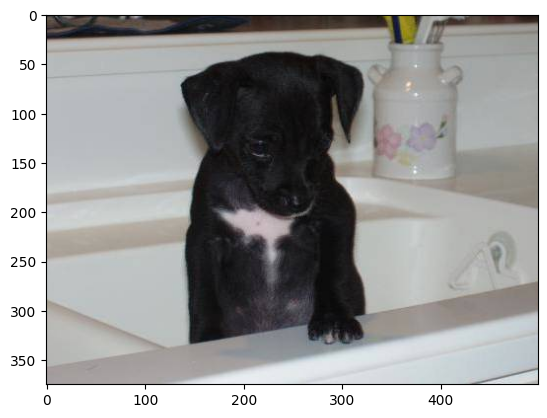

In [10]:
# display dog image
img = mpimg.imread('/content/train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

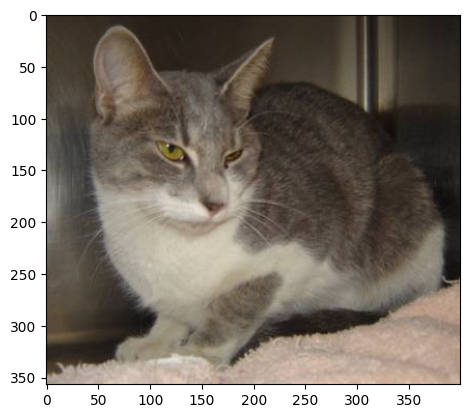

In [11]:
# display cat image
img = mpimg.imread('/content/train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [12]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])



dog
cat
dog
cat
dog


In [13]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


Resizing all the images

In [14]:
#creating a directory for resized images
os.mkdir('/content/image_resized')

In [15]:
original_folder = '/content/train/'
resized_folder = '/content/image_resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

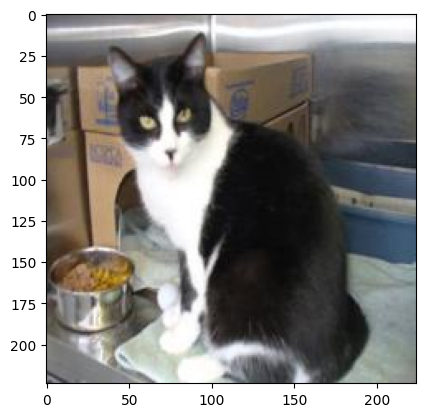

In [16]:
# display resized dog image
img = mpimg.imread('/content/image_resized/cat.11482.jpg')
imgplt = plt.imshow(img)
plt.show()

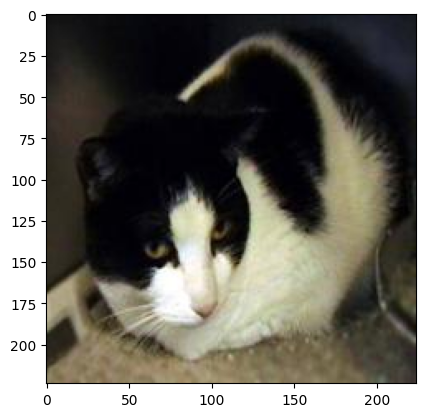

In [17]:
# display resized cat image
img = mpimg.imread('/content/image_resized/cat.10069.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating labels for resized images of dogs and cats**

Cat --> 0

Dog --> 1

In [18]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image_resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [19]:
 print(filenames[0:5])
print(len(filenames))

['dog.10703.jpg', 'cat.8025.jpg', 'dog.3599.jpg', 'cat.7376.jpg', 'dog.2487.jpg']
2000


In [20]:
print(labels[0:5])
print(len(labels))

[1, 0, 1, 0, 1]
2000


In [21]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 992 1008]


Converting all the resized images to numpy arrays

In [22]:
import cv2
import glob

In [23]:
image_directory = '/content/image_resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [24]:
print(dog_cat_images)

[[[[ 67  65  54]
   [ 54  52  41]
   [ 82  81  67]
   ...
   [129  40  13]
   [177  87  57]
   [205 115  84]]

  [[ 63  61  50]
   [ 54  53  39]
   [ 76  75  61]
   ...
   [135  46  19]
   [182  92  61]
   [205 116  82]]

  [[ 75  74  60]
   [ 69  68  54]
   [ 77  74  60]
   ...
   [147  57  27]
   [188  98  64]
   [205 115  80]]

  ...

  [[159 177 188]
   [ 63  80  93]
   [ 30  49  64]
   ...
   [180 165 156]
   [180 152 135]
   [176 143 123]]

  [[ 92 109 122]
   [ 73  90 103]
   [ 94 113 128]
   ...
   [177 162 153]
   [186 158 141]
   [180 146 123]]

  [[ 64  81  94]
   [ 82  99 112]
   [121 139 156]
   ...
   [173 159 147]
   [194 164 147]
   [188 151 129]]]


 [[[158 156 145]
   [157 155 144]
   [157 155 144]
   ...
   [ 57  71  60]
   [ 61  75  64]
   [ 44  58  47]]

  [[158 156 145]
   [157 155 144]
   [157 155 144]
   ...
   [ 52  66  55]
   [ 57  71  60]
   [ 50  64  53]]

  [[158 157 143]
   [157 156 142]
   [157 156 142]
   ...
   [ 52  66  55]
   [ 51  65  54]
   [ 51  65

In [25]:
type(dog_cat_images)

numpy.ndarray

In [26]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [27]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [29]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 --> training images

400 --> test images

In [30]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [31]:
print(X_train_scaled)

[[[[0.83137255 0.81176471 0.65882353]
   [0.83137255 0.81176471 0.65882353]
   [0.83137255 0.81176471 0.65882353]
   ...
   [0.30980392 0.45098039 0.54509804]
   [0.31372549 0.45490196 0.54901961]
   [0.32156863 0.4627451  0.55686275]]

  [[0.83921569 0.81960784 0.66666667]
   [0.83921569 0.81960784 0.66666667]
   [0.83921569 0.81960784 0.66666667]
   ...
   [0.30588235 0.44705882 0.54117647]
   [0.30980392 0.45098039 0.54509804]
   [0.31764706 0.45882353 0.55294118]]

  [[0.84705882 0.82745098 0.6745098 ]
   [0.85098039 0.83137255 0.67843137]
   [0.85098039 0.83137255 0.67843137]
   ...
   [0.30980392 0.45098039 0.54509804]
   [0.30980392 0.45098039 0.54509804]
   [0.31372549 0.45490196 0.54901961]]

  ...

  [[0.58431373 0.55294118 0.43529412]
   [0.57647059 0.54509804 0.42745098]
   [0.58039216 0.54901961 0.43137255]
   ...
   [0.62745098 0.59215686 0.4627451 ]
   [0.61568627 0.58039216 0.45098039]
   [0.6        0.56470588 0.43529412]]

  [[0.58431373 0.55294118 0.43529412]
   [0.5

**Building the Neural Network**

In [32]:
import tensorflow as tf
import tensorflow_hub as hub

In [34]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [41]:
import tensorflow as tf

num_of_classes = 2  # Number of output classes (dog and cat)

# Build the simple CNN model
model = tf.keras.Sequential([
    # First Convolutional Layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Layer
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten the results and feed into Dense layers
    tf.keras.layers.Flatten(),

    # Fully connected Dense layer
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with softmax activation for classification
    tf.keras.layers.Dense(num_of_classes, activation='softmax')
])

# Print the model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  bias_initializer="zeros",


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [43]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/nn.py:609: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?


50/50 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - acc: 0.5386 - loss: 0.9969
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - acc: 0.6487 - loss: 0.6356
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 208s 4s/step - acc: 0.7035 - loss: 0.5745
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 257s 4s/step - acc: 0.7180 - loss: 0.5144
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - acc: 0.8243 - loss: 0.4031


In [44]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - acc: 0.6971 - loss: 0.6074
Test Loss = 0.6355789303779602
Test Accuracy = 0.6800000071525574


**Predictive System**

Path of the image to be predicted: /content/train/cat.0.jpg


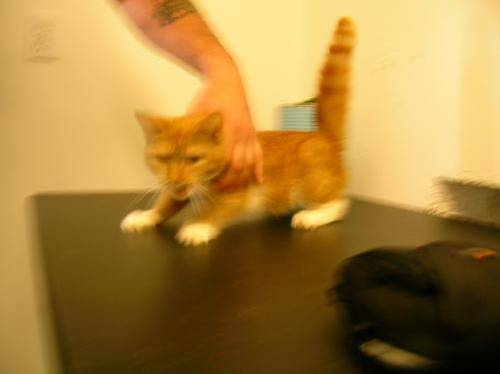

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
[[0.35186294 0.6481371 ]]
1
The image represents a Dog


In [45]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

Path of the image to be predicted: /content/train/cat.1000.jpg


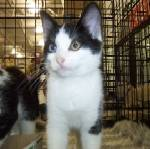

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
[[0.738974   0.26102605]]
0
The image represents a Cat


In [46]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')